In [53]:
import pandas as pd
import numpy as np
import torch

In [54]:
data = open('names.txt', 'r').read().split()

DATA DISCOVERY

In [55]:
# DATA DISCOVERY

In [56]:
data[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [57]:
stoi = {s:i for i,s in enumerate(sorted(list(set(''.join(data)))))}
stoi['<s>'] = 26
stoi['</s>'] = 27
itos = {i:s for s,i in stoi.items()}


In [58]:
itos

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '<s>',
 27: '</s>'}

In [59]:
N = torch.zeros([28,28], dtype=torch.int32)
for ele in data:
    wrd = ['<.>'] + list(ele) + ['<.>']
    

    for ch1,ch2 in zip(wrd,wrd[1:]):
        idx1,idx2 = stoi[ch1],stoi[ch2]
        N[idx1,idx2] += 1

KeyError: '<.>'

In [ ]:
# sorted(N.items(), key=lambda kv: -kv[1])
# N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bigram_matrix(
    N,
    itos,
    *,
    figsize=(12, 12),
    cmap='Blues',
    bigram_fontsize=8,
    count_fontsize=6,
    bigram_color='grey',
    count_color='grey',
    show=True,
):
    """
    Plot a bigram matrix with bigram labels on top and counts on the bottom.

    Parameters
    ----------
    N : array‑like (shape (n, n))
        Matrix of bigram counts.
    itos : dict or list
        Mapping from index → character.  If it is a list, the index is
        assumed to be the list index.
    figsize : tuple of float, optional
        Size of the figure in inches.
    cmap : str or Colormap, optional
        Colormap for the heatmap.
    bigram_fontsize : int, optional
        Font size of the bigram labels.
    count_fontsize : int, optional
        Font size of the count labels.
    bigram_color : str, optional
        Color of the bigram labels.
    count_color : str, optional
        Color of the count labels.
    show : bool, optional
        If ``True`` (default) the plot will be shown with
        ``plt.show()``.  If ``False`` the function returns the
        figure/axes objects.

    Returns
    -------
    fig, ax : matplotlib Figure, Axes
        Only returned when ``show=False``.
    """

    # Ensure we can index into `itos`
    if isinstance(itos, dict):
        words = [itos[i] for i in range(len(itos))]
    else:                 # assume list or tuple
        words = itos

    n = N.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(N, cmap=cmap)

    # Draw the text annotations
    for i in range(n):
        for j in range(n):
            bigram = f"{words[i]}{words[j]}"
            count  = N[i, j]
            # For Torch tensors: count.item()
            if hasattr(count, "item"):
                count = count.item()
            ax.text(j, i, bigram, ha='center', va='top',
                    fontsize=bigram_fontsize, color=bigram_color)
            ax.text(j, i, str(count), ha='center', va='bottom',
                    fontsize=count_fontsize, color=count_color)

    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    if show:
        plt.show()
    else:
        return fig, ax

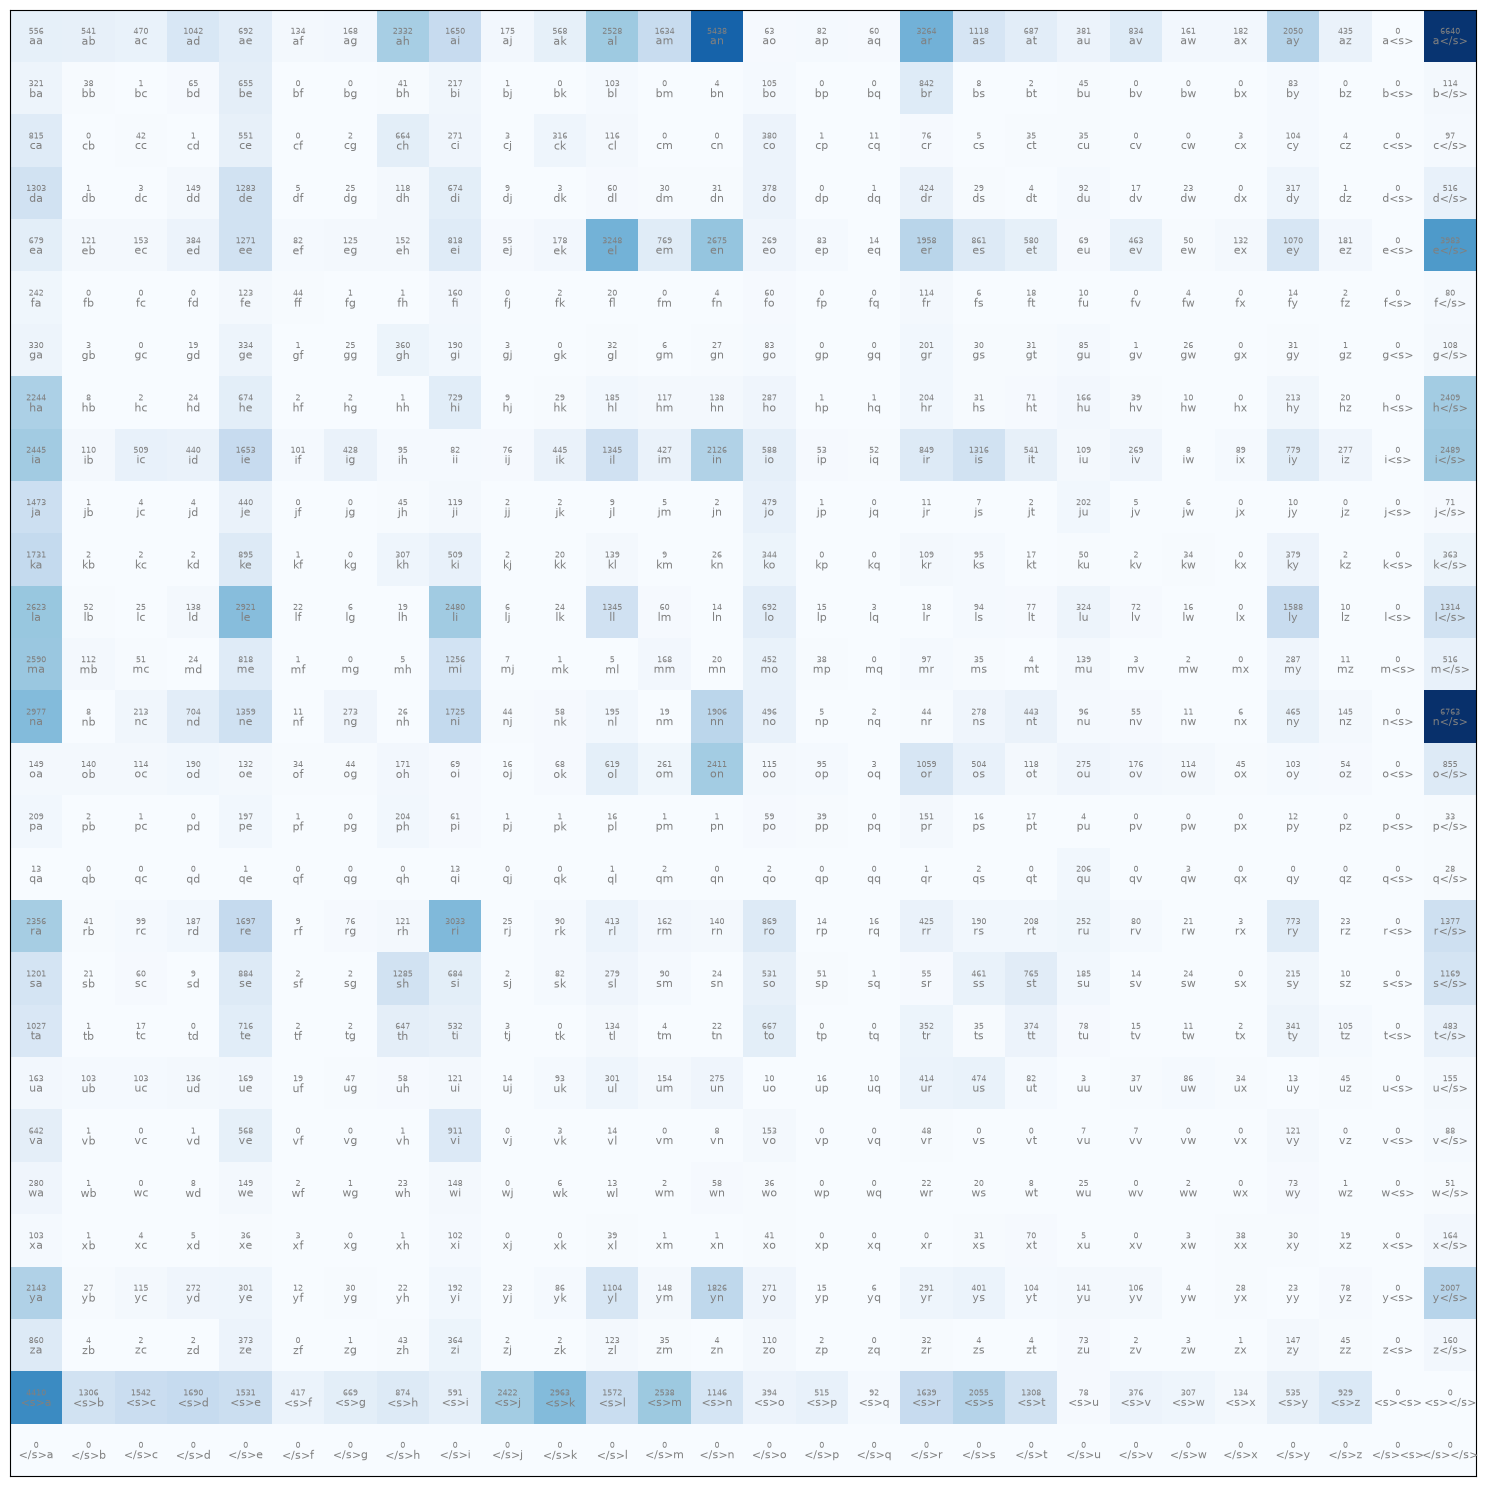

In [ ]:
# Example: `N` is a 28×28 PyTorch tensor and `itos` is a dict mapping indices to characters
plot_bigram_matrix(N, itos, figsize=(15, 15), cmap='Blues')

In [ ]:
stoi = {s:i + 1 for i,s in enumerate(sorted(list(set(''.join(data)))))}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}


N = torch.zeros([27,27], dtype=torch.int32)
for ele in data:
    wrd = ['.'] + list(ele) + ['.']
    

    for ch1,ch2 in zip(wrd,wrd[1:]):
        idx1,idx2 = stoi[ch1],stoi[ch2]
        N[idx1,idx2] += 1

In [ ]:
# stoi

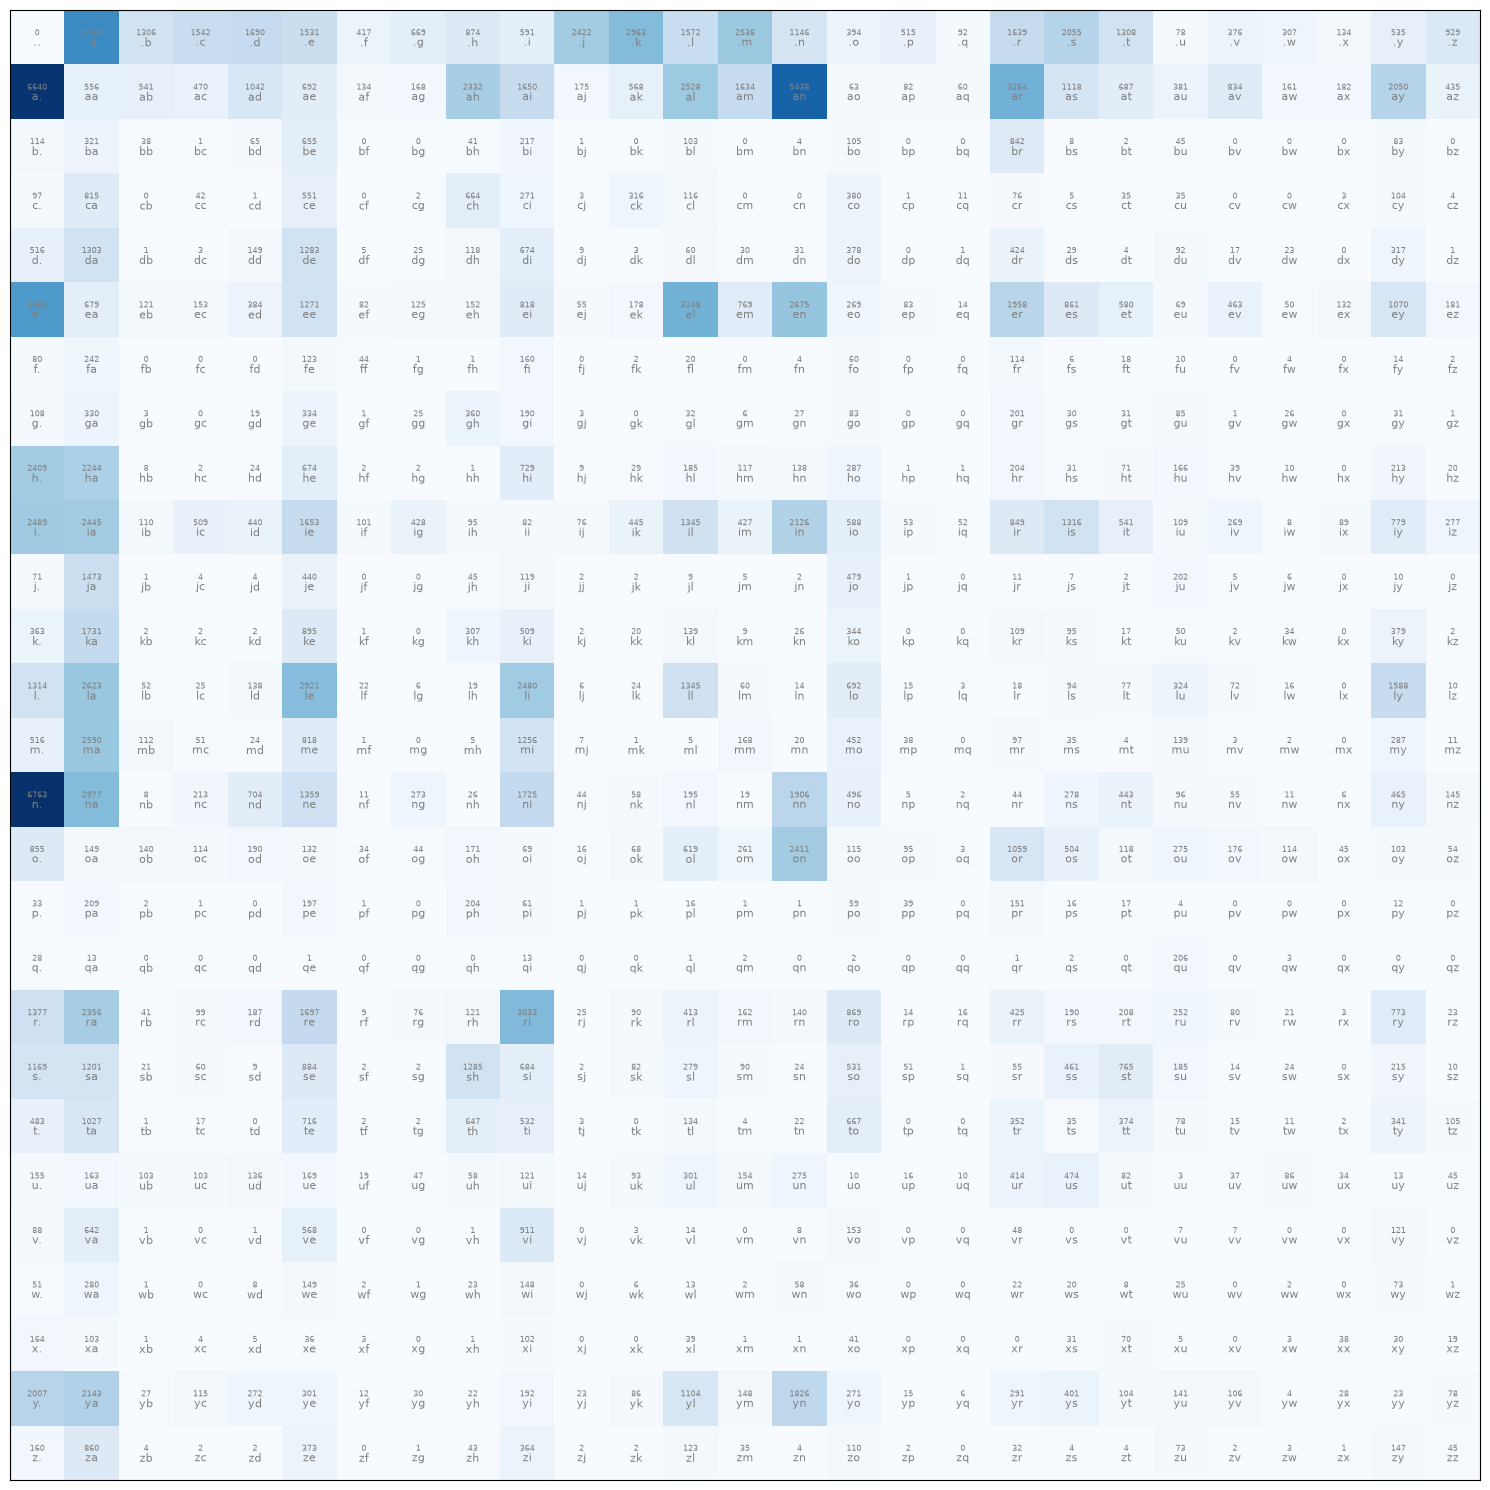

In [ ]:
# Example: `N` is a 28×28 PyTorch tensor and `itos` is a dict mapping indices to characters
plot_bigram_matrix(N, itos, figsize=(15, 15), cmap='Blues')

In [ ]:
P = N.float()
P /= P.sum(1, keepdim=True)

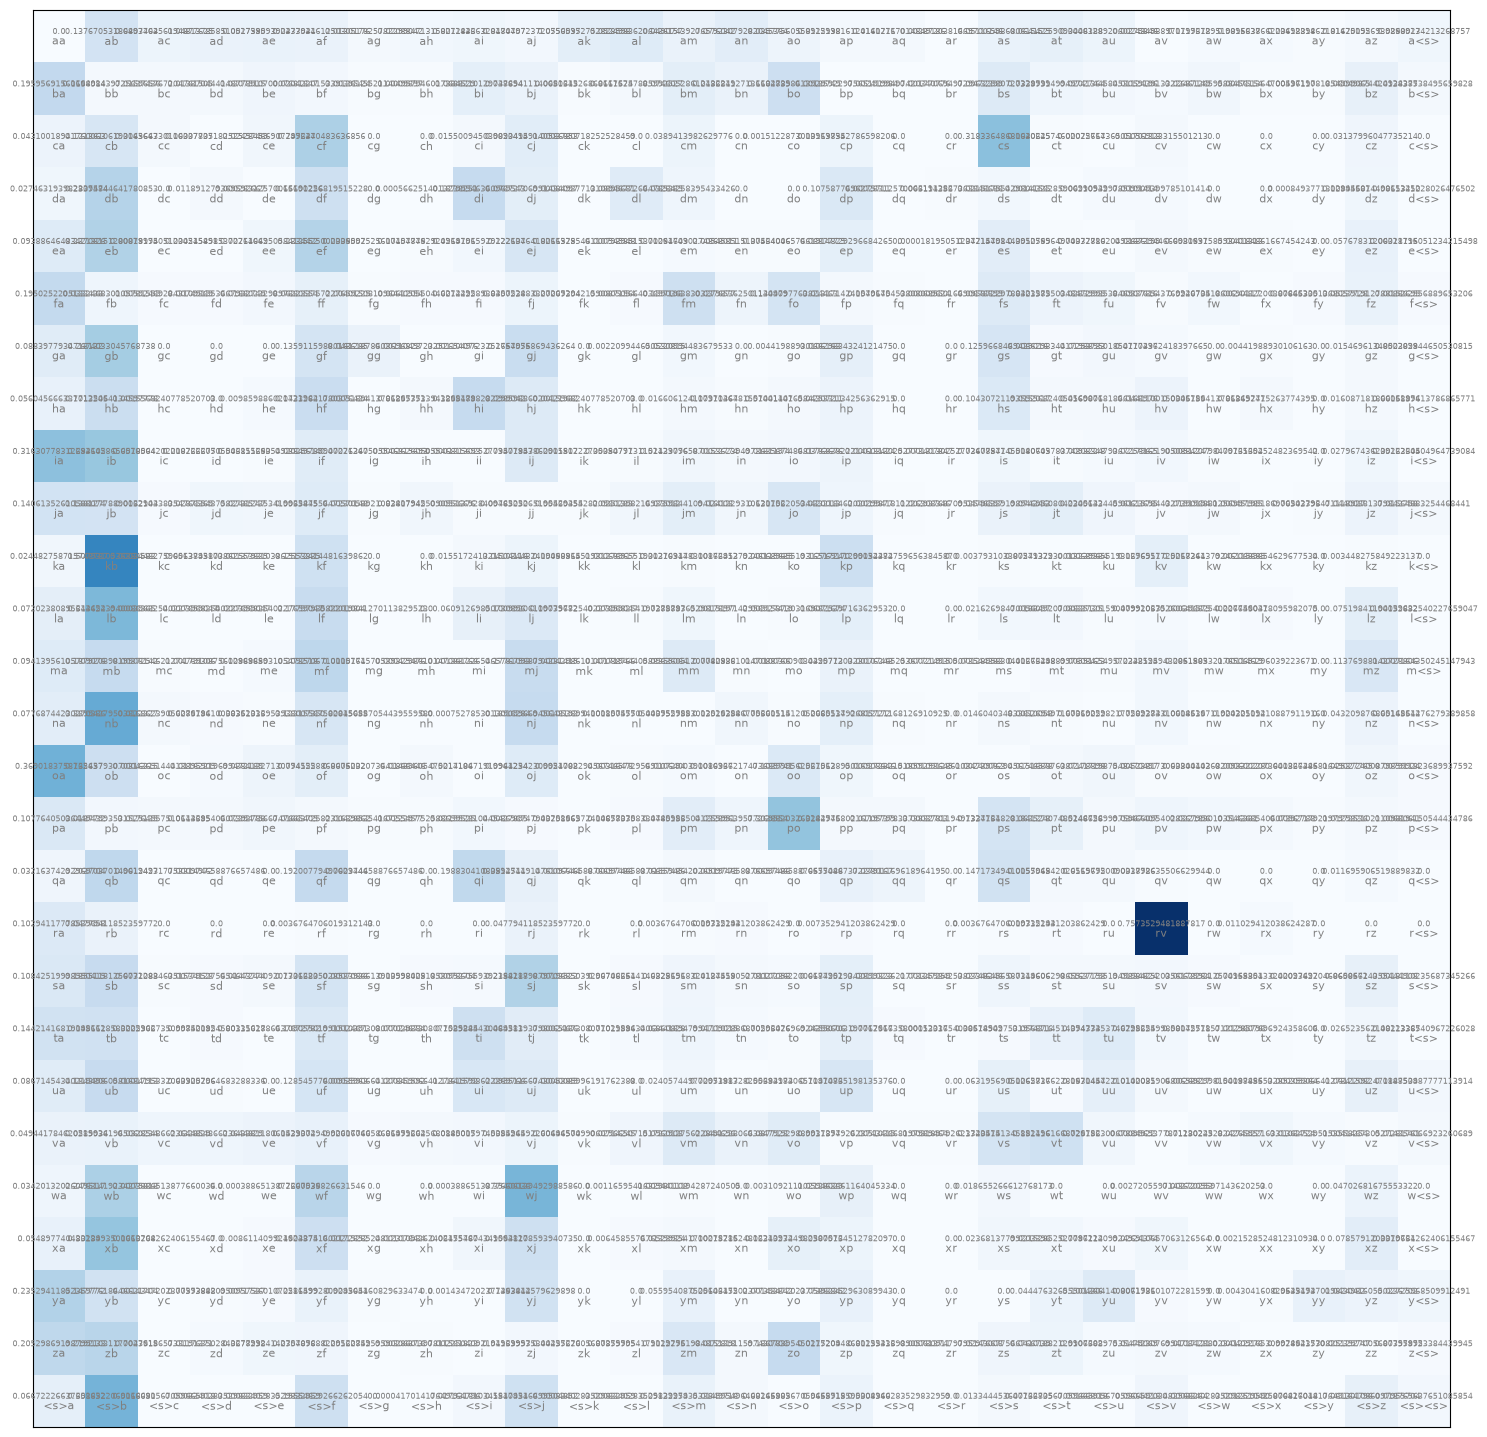

In [60]:
# Example: `N` is a 28×28 PyTorch tensor and `itos` is a dict mapping indices to characters
plot_bigram_matrix(P, itos, figsize=(15, 15), cmap='Blues')

In [ ]:
idx = 0
while True:
    g = torch.Generator().manual_seed(2147483647)
    idx = torch.multinomial(P[idx], 1, replacement=True,generator=g).item()
    print(itos[idx])
    if idx == 0:
        break

c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c
c


KeyboardInterrupt: 